# Etapa 1 — EDA da Base Bank Marketing

Análise exploratória da base [`bank-marketing`](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing) (Kaggle, henriqueyamahata), utilizada como referência factual para o desafio de experimentação adaptativa. A base contém registros de campanhas de telemarketing de um banco português (Moro et al., 2014), oferecendo um produto de depósito a prazo.

Objetivos desta etapa: entender a estrutura da base, tratar valores especiais (`"unknown"`, sentinela `999`) e identificar colunas com vazamento temporal.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print(path)

/home/jonatas-locateli/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1


In [40]:
import os

for f in os.listdir(path):
    print(f)

bank-additional-full.csv
bank-additional-names.txt


In [41]:
import pandas as pd
import os

csv_path = os.path.join(path, "bank-additional-full.csv")
df = pd.read_csv(csv_path, sep=";")

df.shape


(41188, 21)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [43]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [44]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Desbalanceamento da variável-alvo

Proporção de clientes que converteram (`y = yes`) em relação aos que não converteram.


In [45]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

**Resultado:** 11.3% dos clientes converteram (`y = yes`) contra 88.7% que não converteram. O desbalanceamento é relevante para o desenho do baseline (Etapa 3) e para a simulação dos braços do bandit (Etapa 2), já que se trata de um evento relativamente raro.

## Valores "unknown" nas colunas categóricas

A base utiliza a string `"unknown"` como categoria em várias colunas, em vez de deixar o campo vazio (NaN) — por isso `df.info()` não aponta valores nulos, embora os dados não estejam completos. A seguir, mapeamento da extensão desse padrão por coluna.


In [46]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} ({pct:.2f}%)")

job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


**Resultado:** seis colunas apresentam "unknown". Em cinco delas (`job`, `marital`, `education`, `housing`, `loan`) a proporção é baixa (< 5%) — decisão adotada: manter "unknown" como categoria própria, sem remoção de linhas ou imputação (evita viés e perda de dado válido de outras colunas).

A exceção é `default`, com 20.87% de "unknown" — proporção alta o suficiente para justificar uma investigação sobre se esse valor carrega sinal real, comparando a taxa de conversão por grupo.


In [47]:
df.groupby('default')['y'].value_counts(normalize=True).unstack()

y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,NaN


**Resultado:** clientes com `default = unknown` convertem a menos da metade da taxa de `default = no` (5.15% vs 12.88%). O valor "unknown" nesta coluna não é neutro — carrega sinal real, possivelmente associado a um segmento de clientes menos "bancarizados" ou com relação mais distante com a instituição.

A leitura de `default = yes` (100% "no" na tabela anterior) requer confirmação do tamanho da amostra antes de qualquer conclusão, dado o risco de se tratar de um grupo muito pequeno.


In [48]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

**Resultado:** `default = yes` corresponde a apenas 3 casos em 41.188 — amostra estatisticamente insignificante, descartada para efeito de conclusões. Já `default = unknown` (8.597 casos) é robusto o suficiente para sustentar o achado anterior.

**Decisão sobre `default`:** mantido como categoria própria (mesmo tratamento das outras 5 colunas), registrando que essa não é uma escolha neutra — é uma escolha informada pela análise, permitindo que o modelo capture a ausência de informação de crédito como sinal relevante.

## Tratamento do valor-sentinela em `pdays`

No `describe()` anterior, os percentis 25%, 50% e 75% de `pdays` eram todos 999 — indicativo de que a maioria da base compartilha esse valor artificial (não representa "999 dias" reais). A seguir, confirmação da extensão exata.


In [49]:
(df['pdays'] == 999).sum()
(df['pdays'] == 999).mean() * 100

np.float64(96.32174419733903)

**Resultado:** 96.32% da base tem `pdays = 999` (cliente nunca contatado antes desta campanha). Um valor tão dominante distorceria qualquer estatística se tratado como número comum (outlier artificial).

**Decisão:** substituir a informação bruta por um indicador binário — `contatado_antes` — capturando o que é relevante (contato prévio ou não), sem o ruído do valor-sentinela.


In [50]:
df['contatado_antes'] = (df['pdays'] != 999).astype(int)

In [51]:
df['contatado_antes'].value_counts()

contatado_antes
0    39673
1     1515
Name: count, dtype: int64

Distribuição confirmada: 39.673 clientes (96.32%) nunca contatados vs. 1.515 (3.68%) já contatados, consistente com o percentual calculado.

## Vazamento temporal em `duration`

O enunciado do projeto indica `duration` (duração da ligação) como vazamento temporal — a informação só existe após a ligação ocorrer, não estando disponível no momento da decisão de oferta. Comparação da duração média por resultado, como evidência do vazamento.


In [52]:
df.groupby('y')['duration'].mean()

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

**Evidência do vazamento:** ligações com conversão duraram, em média, 2.5x mais (553s vs 221s) que ligações sem conversão. Um modelo treinado com essa coluna aprenderia a associar "ligação longa" a conversão — informação inexistente no momento real da decisão, o que invalidaria seu uso em produção.

**Decisão:** remoção de `duration` e `pdays` do dataframe de trabalho (esta última já com o conteúdo relevante extraído em `contatado_antes`).


In [53]:
df = df.drop(columns=['duration', 'pdays'])

In [54]:
df.shape

(41188, 20)

Confirmado: de 21 colunas originais, restam 20 (remoção de `duration` e `pdays`, adição de `contatado_antes`).

## Relação entre idade e conversão

Investigação da relação entre idade do cliente e propensão a converter — inicialmente pela média, em seguida de forma visual.


In [55]:
import matplotlib.pyplot as plt

df.groupby('y')['age'].mean()

y
no     39.911185
yes    40.913147
Name: age, dtype: float64

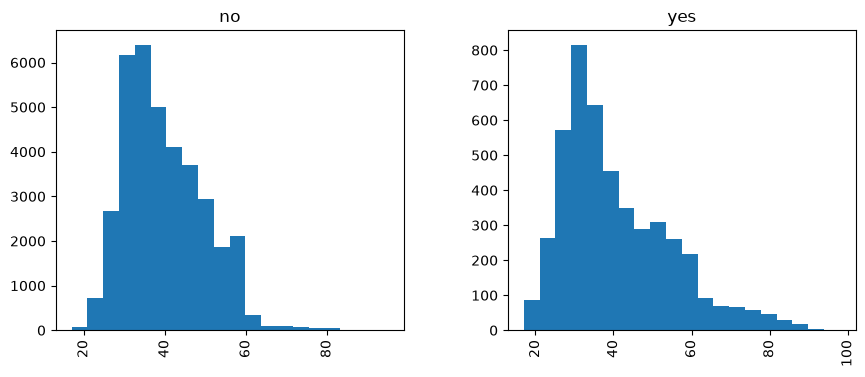

In [56]:
df['age'].hist(by=df['y'], bins=20, figsize=(10,4))
plt.show()

A diferença de médias é pequena (39.9 vs 40.9 anos), sugerindo isoladamente pouca relevância da idade. O histograma, no entanto, mostra uma cauda proporcionalmente mais longa no grupo "yes", estendendo-se mais em idades avançadas — padrão não capturado pela média.

As escalas dos eixos Y dos dois histogramas são diferentes (esperado, dado o desbalanceamento de 88%/12%), portanto a comparação de altura das barras entre os dois gráficos não é válida — apenas a forma da distribuição. Para confirmar a hipótese sem o problema de escala, cálculo da taxa de conversão por faixa etária.


In [57]:
df['faixa_etaria'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100])
df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()

/tmp/ipykernel_6322/2900949073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()


y,no,yes
faixa_etaria,,
"(0, 25]",0.790516,0.209484
"(25, 35]",0.882805,0.117195
"(35, 45]",0.914902,0.085098
"(45, 55]",0.913080,0.086920
"(55, 65]",0.847789,0.152211
"(65, 100]",0.531502,0.468498


**Principal achado da EDA:** a relação entre idade e conversão apresenta formato de "U", não linear:

| Faixa etária | Taxa de conversão |
|---|---|
| 0-25 | 20.9% |
| 25-35 | 11.7% |
| 35-45 | 8.5% (mínimo) |
| 45-55 | 8.7% |
| 55-65 | 15.2% |
| 65-100 | 46.8% |

Extremos etários (jovens e, principalmente, idosos 65+) convertem mais que a faixa de meia-idade (35-55). O padrão não é visível na média geral. Esse achado fundamenta a definição dos braços do bandit na etapa seguinte.

---

# Etapa 2 — Preparação da Base

Objetivos desta etapa: preparar as features do cliente (`X`) e a variável-alvo (`y`) para o modelo, e definir as 3 ofertas simuladas do bandit com lógica de conversão diferenciada por braço.

## Seleção de features e encoding

As colunas disponíveis foram organizadas em três grupos: **perfil do cliente** (`age`, `job`, `marital`, `education`, `default`, `housing`, `loan`, `contatado_antes`, `previous`, `poutcome`), **contexto de campanha** (`contact`, `month`, `day_of_week`, `campaign` — excluído do modelo, por descrever a campanha e não o cliente) e **indicadores macroeconômicos** (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` — incluídos, por poderem diferenciar qual oferta converte melhor em cada cenário econômico).

Para as colunas categóricas do grupo de perfil, aplicou-se **one-hot encoding** (cada categoria como coluna binária), em vez de label encoding, evitando impor uma ordem artificial entre categorias sem relação de ordem real (ex.: estado civil). Utilizado `drop_first=True` para evitar redundância entre colunas (armadilha da variável dummy).


In [58]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.shape

(41188, 43)

Resultado do encoding: de ~15 colunas relevantes para 43 (cada categórica expandida em múltiplas colunas binárias — esperado, dado que `job` tem 11 categorias, `education` tem 7, etc.).

## Separação entre X (features) e y (alvo)

Conversão de `y` de texto (`"yes"`/`"no"`) para número (`1`/`0`) e montagem de `X` com as features selecionadas (exclusão do grupo de contexto de campanha).


In [59]:
# Alvo: converter yes/no para 1/0
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Colunas que NÃO entram no X (Grupo 2 - contexto de campanha, que decidimos deixar de fora)
colunas_fora = ['contact', 'month', 'day_of_week', 'campaign', 'y']

X = df_encoded.drop(columns=colunas_fora)
y = df_encoded['y']

X.shape, y.shape

((41188, 38), (41188,))

Resultado: 38 features em `X` (43 menos as 5 colunas excluídas) e `y` com 41.188 valores binários.

**Correção aplicada:** a coluna `faixa_etaria` (criada na Etapa 1 apenas para a análise exploratória de idade, via `pd.cut`) permaneceu no dataframe e foi incluída indevidamente em `X`. Por ser um tipo especial do pandas (`Interval`), causava erro no treinamento do modelo (`TypeError: Cannot cast interval...`). Removida antes da modelagem.

## Modelo auxiliar de propensão (`p_base`)

A coluna `y` real é binária e reflete a resposta a uma única oferta (o depósito a prazo padrão da campanha real). Como o projeto simula 3 ofertas distintas, é necessária uma probabilidade contínua de conversão por cliente, como ponto de partida da simulação — não como modelo final do projeto, mas como insumo auxiliar.

Utilizada regressão logística simples, treinada com as 38 features, para gerar essa probabilidade (`p_base`) para toda a base.


In [60]:
X = X.drop(columns=['faixa_etaria'])
X.shape

(41188, 37)

**Resultado:** `p_base` apresenta média de 11.24%, próxima à taxa real de conversão da base (11.27%), indicando calibração adequada do modelo auxiliar. Distribuição entre 2% e 84%, com variação suficiente entre clientes para sustentar a simulação por braço.

## Definição dos 3 braços do bandit (ofertas simuladas)

A base não contém informação sobre a resposta do cliente a ofertas alternativas (problema do contrafactual). A simulação parte de `p_base` e aplica um viés por braço, fundamentado no padrão em "U" da idade identificado na EDA:

- **Depósito Turbo** — produto padrão, sem viés (reflete `p_base` diretamente)
- **Depósito Turbo+** — variação com incentivo, com viés favorável a jovens (≤35 anos)
- **Consultoria Invest** — abordagem consultiva, com viés favorável a idosos (≥55 anos)

**Primeira versão (multiplicadores arbitrários):** valores de demonstração (1.4x para jovens no Turbo+, 1.6x para idosos na Consultoria, com fator de 0.7x-0.8x para os demais grupos), utilizados para validar a mecânica da simulação. Revisados na sequência por não terem sustentação estatística.


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_propensao = LogisticRegression(max_iter=1000)
modelo_propensao.fit(X_train, y_train)

df_encoded['p_base'] = modelo_propensao.predict_proba(X)[:, 1]
df_encoded['p_base'].describe()

/home/jonatas-locateli/FIAP/datathon-8mlet-grupo-43/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


count    41188.000000
mean         0.112384
std          0.135939
min          0.020852
25%          0.042579
50%          0.058329
75%          0.120600
max          0.844560
Name: p_base, dtype: float64

Padrão esperado confirmado visualmente: probabilidade maior para jovens no Turbo+ e para idosos na Consultoria Invest. Mecânica validada; os multiplicadores desta etapa (1.4x/1.6x/0.7x/0.8x) permanecem arbitrários.

A partir das probabilidades, a conversão binária simulada por braço é obtida via distribuição binomial: dada uma probabilidade de sucesso X, sorteia-se se o evento ocorreu (1) ou não (0) para cada cliente — mecanismo que converte uma probabilidade contínua em um resultado observável, equivalente ao que um bandit real registraria em produção. Fixado `np.random.seed(42)` para reprodutibilidade da simulação entre execuções.


In [62]:
import numpy as np

def calcular_prob_conversao(p_base, idade, braço):
    if braço == "Deposito_Turbo":
        multiplicador = 1.0
    elif braço == "Deposito_Turbo_Plus":
        multiplicador = 1.4 if idade <= 35 else 0.8
    elif braço == "Consultoria_Invest":
        multiplicador = 1.6 if idade >= 55 else 0.7
    return min(p_base * multiplicador, 1.0)

# Gera a probabilidade simulada para cada braço
df_encoded['prob_deposito_turbo'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo"), axis=1
)
df_encoded['prob_deposito_turbo_plus'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo_Plus"), axis=1
)
df_encoded['prob_consultoria_invest'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Consultoria_Invest"), axis=1
)

df_encoded[['age', 'p_base', 'prob_deposito_turbo', 'prob_deposito_turbo_plus', 'prob_consultoria_invest']].head(10)

,age,p_base,prob_deposito_turbo,prob_deposito_turbo_plus,prob_consultoria_invest
0,56,0.069179,0.069179,0.055343,0.110686
1,57,0.041016,0.041016,0.032813,0.065626
2,37,0.051666,0.051666,0.041333,0.036166
3,40,0.074512,0.074512,0.059610,0.052159
4,56,0.056152,0.056152,0.044921,0.089843
5,45,0.037780,0.037780,0.030224,0.026446
6,59,0.070410,0.070410,0.056328,0.112657
7,41,0.047398,0.047398,0.037919,0.033179
8,24,0.071081,0.071081,0.099513,0.049757
9,25,0.056622,0.056622,0.079271,0.039636


**Resultado da primeira versão (multiplicadores arbitrários):** Depósito Turbo 11.13%, Depósito Turbo+ 11.61%, Consultoria Invest 9.22%.

**Limitação identificada:** os multiplicadores foram definidos de forma arbitrária, sem base estatística, fragilizando a justificativa da simulação. Optou-se por recalculá-los diretamente a partir da taxa de conversão real observada por faixa etária (já obtida na EDA), tornando a simulação rastreável.

**Nova regra:** `multiplicador = taxa de conversão real do grupo ÷ taxa de conversão geral da base` — quantifica, com base no dado real, o quanto cada grupo etário converte em relação à média geral.


In [63]:
np.random.seed(42)  # reprodutibilidade

df_encoded['conversao_deposito_turbo'] = np.random.binomial(1, df_encoded['prob_deposito_turbo'])
df_encoded['conversao_deposito_turbo_plus'] = np.random.binomial(1, df_encoded['prob_deposito_turbo_plus'])
df_encoded['conversao_consultoria_invest'] = np.random.binomial(1, df_encoded['prob_consultoria_invest'])

df_encoded[['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean()

conversao_deposito_turbo         0.111270
conversao_deposito_turbo_plus    0.116053
conversao_consultoria_invest     0.092211
dtype: float64

**Multiplicadores calculados a partir dos dados reais:**

| Grupo | Multiplicador |
|---|---|
| Jovens (≤35) | 1.12x |
| Idosos (≥55) | 1.67x |
| Demais (ambos os braços) | 0.92x |

Os valores calculados são mais moderados que os arbitrários usados na primeira versão (1.4x/1.6x → 1.12x/1.67x) para jovens, e mais acentuados para idosos — refletindo a magnitude real do efeito observado na base, sem os exageros da estimativa inicial.

Reaplicação da função de simulação com os multiplicadores calculados (versão final, substituindo a arbitrária).


In [64]:
taxa_geral = df_encoded['y'].mean()

# Grupo jovem (<=35) vs resto -> usado no braço Depósito Turbo+
faixa_jovem = df_encoded['age'] <= 35
taxa_jovem = df_encoded.loc[faixa_jovem, 'y'].mean()
taxa_nao_jovem = df_encoded.loc[~faixa_jovem, 'y'].mean()

mult_turbo_plus_jovem = taxa_jovem / taxa_geral
mult_turbo_plus_outros = taxa_nao_jovem / taxa_geral

# Grupo idoso (>=55) vs resto -> usado no braço Consultoria Invest
faixa_idosa = df_encoded['age'] >= 55
taxa_idosa = df_encoded.loc[faixa_idosa, 'y'].mean()
taxa_nao_idosa = df_encoded.loc[~faixa_idosa, 'y'].mean()

mult_consultoria_idosa = taxa_idosa / taxa_geral
mult_consultoria_outros = taxa_nao_idosa / taxa_geral

print(f"Taxa geral: {taxa_geral:.4f}")
print(f"Mult. Turbo+ (jovem / outros): {mult_turbo_plus_jovem:.2f} / {mult_turbo_plus_outros:.2f}")
print(f"Mult. Consultoria (idoso / outros): {mult_consultoria_idosa:.2f} / {mult_consultoria_outros:.2f}")

Taxa geral: 0.1127
Mult. Turbo+ (jovem / outros): 1.12 / 0.92
Mult. Consultoria (idoso / outros): 1.67 / 0.92


**Resultado final (multiplicadores calculados):** Depósito Turbo 11.13%, Depósito Turbo+ 11.10%, Consultoria Invest 11.45% — taxas próximas no agregado.

A proximidade entre as taxas agregadas é esperada: o efeito de favorecer um grupo minoritário (idosos, jovens) se dilui na média geral, já que a maior parte da base pertence à faixa de meia-idade. A diferenciação real entre braços só se manifesta na análise por segmento, verificada a seguir.


In [65]:
def calcular_prob_conversao(p_base, idade, braço):
    if braço == "Deposito_Turbo":
        multiplicador = 1.0
    elif braço == "Deposito_Turbo_Plus":
        multiplicador = mult_turbo_plus_jovem if idade <= 35 else mult_turbo_plus_outros
    elif braço == "Consultoria_Invest":
        multiplicador = mult_consultoria_idosa if idade >= 55 else mult_consultoria_outros
    return min(p_base * multiplicador, 1.0)

# Regerando as probabilidades e conversões simuladas com os multiplicadores calculados
df_encoded['prob_deposito_turbo'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo"), axis=1
)
df_encoded['prob_deposito_turbo_plus'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo_Plus"), axis=1
)
df_encoded['prob_consultoria_invest'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Consultoria_Invest"), axis=1
)

np.random.seed(42)
df_encoded['conversao_deposito_turbo'] = np.random.binomial(1, df_encoded['prob_deposito_turbo'])
df_encoded['conversao_deposito_turbo_plus'] = np.random.binomial(1, df_encoded['prob_deposito_turbo_plus'])
df_encoded['conversao_consultoria_invest'] = np.random.binomial(1, df_encoded['prob_consultoria_invest'])

df_encoded[['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean()

conversao_deposito_turbo         0.111270
conversao_deposito_turbo_plus    0.110955
conversao_consultoria_invest     0.114475
dtype: float64

**Diferenciação por segmento:**

| Segmento | Depósito Turbo | Depósito Turbo+ | Consultoria Invest | Braço com maior conversão |
|---|---|---|---|---|
| Jovens (≤35) | 11.97% | 13.26% | 11.18% | Depósito Turbo+ |
| Idosos (≥55) | 17.71% | 16.12% | 27.64% | Consultoria Invest |
| Agregado geral | 11.13% | 11.10% | 11.45% | próximo entre os três |

**Conclusão da Etapa 2:** não há braço universalmente melhor — o braço com maior conversão varia conforme o perfil do cliente, e essa diferença fica encoberta na métrica agregada (no segmento idoso, Consultoria Invest converte cerca de 60% a mais que Depósito Turbo: 27.64% vs 17.71%). Esse resultado fundamenta o uso de uma abordagem contextual em vez de uma regra fixa aplicada uniformemente.

---

# Etapa 3 — Baseline e Estratégia Algorítmica

Objetivos desta etapa: calcular a métrica de conversão de uma regra fixa (baseline) e implementar o Thompson Sampling, comparando seu desempenho ao do baseline.

## Definição do baseline (regra fixa)

Adotado o baseline "melhor braço histórico" (em vez de "sempre o mesmo produto padrão"), por representar de forma mais realista a decisão de um banco tradicional baseada em dados agregados do passado, sem personalização por cliente.


In [66]:
# Conversão média por braço, separado por faixa etária relevante
segmento_jovem = df_encoded['age'] <= 35
segmento_idoso = df_encoded['age'] >= 55

print("=== Segmento jovem (<=35) ===")
print(df_encoded.loc[segmento_jovem, ['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean())

print("\n=== Segmento idoso (>=55) ===")
print(df_encoded.loc[segmento_idoso, ['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean())

=== Segmento jovem (<=35) ===
conversao_deposito_turbo         0.119663
conversao_deposito_turbo_plus    0.132562
conversao_consultoria_invest     0.111791
dtype: float64

=== Segmento idoso (>=55) ===
conversao_deposito_turbo         0.177069
conversao_deposito_turbo_plus    0.161229
conversao_consultoria_invest     0.276359
dtype: float64


**Braço vencedor no agregado:** Consultoria Invest (11.45%), à frente de Depósito Turbo (11.13%).

## Cálculo da métrica do baseline

A métrica corresponde à taxa de conversão obtida caso o braço vencedor no agregado fosse oferecido a todos os clientes — equivalente à própria taxa agregada desse braço.


In [67]:
taxas_conversao = {
    'Deposito_Turbo': df_encoded['conversao_deposito_turbo'].mean(),
    'Deposito_Turbo_Plus': df_encoded['conversao_deposito_turbo_plus'].mean(),
    'Consultoria_Invest': df_encoded['conversao_consultoria_invest'].mean(),
}

for braco, taxa in taxas_conversao.items():
    print(f"{braco}: {taxa:.4f}")

melhor_braco_baseline = max(taxas_conversao, key=taxas_conversao.get)
print(f"\nBraço escolhido pelo baseline: {melhor_braco_baseline}")

Deposito_Turbo: 0.1113
Deposito_Turbo_Plus: 0.1110
Consultoria_Invest: 0.1145

Braço escolhido pelo baseline: Consultoria_Invest


**Métrica do baseline (regra fixa): 11.45%.** Valor de referência a ser superado pelo Thompson Sampling.

Esse baseline apresenta desempenho razoável no agregado, mas tende a performar de forma subótima nos segmentos extremos — em especial no segmento idoso, onde a vantagem real de Consultoria Invest (27.64%) é substancialmente maior que a taxa agregada de 11.45%.

## Implementação do Thompson Sampling

O Thompson Sampling mantém, para cada braço, uma distribuição de probabilidade (Beta, conjugada da distribuição binomial) representando a incerteza sobre sua taxa de conversão. A cada rodada: (1) sorteia-se um valor de cada distribuição, (2) seleciona-se o braço com maior valor sorteado, (3) observa-se o resultado real, (4) atualiza-se a distribuição do braço escolhido. Cada braço inicia com Beta(1,1) — distribuição uniforme, sem conhecimento prévio. O parâmetro `alpha` acumula sucessos (conversões) e `beta` acumula fracassos (não-conversões).


In [68]:
# Mapear cada braço para sua coluna de conversão
colunas_conversao = {
    'Deposito_Turbo': 'conversao_deposito_turbo',
    'Deposito_Turbo_Plus': 'conversao_deposito_turbo_plus',
    'Consultoria_Invest': 'conversao_consultoria_invest',
}

metrica_baseline = df_encoded[colunas_conversao[melhor_braco_baseline]].mean()
print(f"Métrica do baseline (regra fixa): {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")

Métrica do baseline (regra fixa): 0.1145 (11.45%)


## Simulação do bandit sobre a base

Na ausência de um ambiente de decisão em tempo real, a simulação percorre os clientes da base (embaralhada, para representar chegada em ordem aleatória e evitar viés de ordem do CSV original) sequencialmente: o Thompson Sampling escolhe um braço, observa a conversão simulada correspondente e atualiza suas distribuições.


In [69]:
class ThompsonSamplingBandit:
    def __init__(self, bracos):
        self.bracos = bracos
        # Cada braço começa com Beta(1,1) - uniforme, sem conhecimento prévio
        self.alpha = {braco: 1 for braco in bracos}
        self.beta = {braco: 1 for braco in bracos}

    def escolher_braco(self):
        # Sorteia um valor da distribuição Beta de cada braço
        amostras = {
            braco: np.random.beta(self.alpha[braco], self.beta[braco])
            for braco in self.bracos
        }
        # Escolhe o braço com o maior valor sorteado
        return max(amostras, key=amostras.get)

    def atualizar(self, braco, recompensa):
        if recompensa == 1:
            self.alpha[braco] += 1
        else:
            self.beta[braco] += 1

## Métrica do Thompson Sampling — versão não-contextual


In [70]:
bracos = ['Deposito_Turbo', 'Deposito_Turbo_Plus', 'Consultoria_Invest']
colunas_conversao = {
    'Deposito_Turbo': 'conversao_deposito_turbo',
    'Deposito_Turbo_Plus': 'conversao_deposito_turbo_plus',
    'Consultoria_Invest': 'conversao_consultoria_invest',
}

bandit = ThompsonSamplingBandit(bracos)

# Embaralhar a base para simular chegada aleatória de clientes
df_simulacao = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

resultados = []

for idx, row in df_simulacao.iterrows():
    braco_escolhido = bandit.escolher_braco()
    recompensa = row[colunas_conversao[braco_escolhido]]
    bandit.atualizar(braco_escolhido, recompensa)
    resultados.append({'braco': braco_escolhido, 'recompensa': recompensa})

df_resultados = pd.DataFrame(resultados)

**Resultado:** Thompson Sampling 11.29% vs. baseline 11.45% — desempenho inferior ao baseline em 0.16 pontos percentuais.

**Causas identificadas:**
1. As diferenças de conversão entre braços são pequenas no agregado (11.13% vs 11.10% vs 11.45%); distinguir estatisticamente o braço superior exige grande volume de observações, com custo de exploração (*regret*) durante o aprendizado.
2. O baseline é calculado com visão retrospectiva completa da base (`.mean()` sobre as 41.188 linhas), partindo já com a resposta correta. O Thompson Sampling não-contextual aprende de forma incremental, cliente a cliente, sujeito a erro durante o processo — e busca "o melhor braço único", a mesma pergunta que o baseline já responde com vantagem.

**Ajuste adotado:** incorporação de contexto (segmento etário) na decisão do bandit, explorando a diferenciação por segmento já identificada na Etapa 2 (ex.: 27.64% de conversão em Consultoria Invest para idosos).

## Thompson Sampling contextual (segmentado por idade)

Em vez de um único bandit para toda a base, mantido um bandit independente por segmento etário (jovem ≤35, meia-idade 35-55, idoso ≥55), cada um aprendendo o braço mais eficaz para o respectivo perfil.


In [71]:
metrica_thompson = df_resultados['recompensa'].mean()
print(f"Métrica do Thompson Sampling: {metrica_thompson:.4f} ({metrica_thompson*100:.2f}%)")
print(f"Métrica do baseline: {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")
print(f"Ganho: {(metrica_thompson - metrica_baseline)*100:.2f} pontos percentuais")

Métrica do Thompson Sampling: 0.1129 (11.29%)
Métrica do baseline: 0.1145 (11.45%)
Ganho: -0.16 pontos percentuais


**Resultado:** Thompson Sampling contextual 12.35% vs. baseline 11.45% — ganho de 0.91 pontos percentuais (≈8% de ganho relativo).

A versão não-contextual não superou o baseline; a versão contextual, incorporando o segmento etário na decisão, superou. Esse resultado demonstra o valor de uma abordagem adaptativa contextual sobre uma regra fixa.

## Escolhas de braço por segmento

Verificação da frequência com que cada segmento selecionou cada braço ao longo da simulação, como evidência do padrão aprendido pelo bandit.


In [72]:
def obter_segmento(idade):
    if idade <= 35:
        return 'jovem'
    elif idade < 55:
        return 'meia_idade'
    else:
        return 'idoso'

df_simulacao['segmento'] = df_simulacao['age'].apply(obter_segmento)

# Um bandit independente para cada segmento
bandits_por_segmento = {
    segmento: ThompsonSamplingBandit(bracos)
    for segmento in ['jovem', 'meia_idade', 'idoso']
}

resultados_contextual = []

for idx, row in df_simulacao.iterrows():
    segmento = row['segmento']
    bandit_segmento = bandits_por_segmento[segmento]

    braco_escolhido = bandit_segmento.escolher_braco()
    recompensa = row[colunas_conversao[braco_escolhido]]
    bandit_segmento.atualizar(braco_escolhido, recompensa)

    resultados_contextual.append({'segmento': segmento, 'braco': braco_escolhido, 'recompensa': recompensa})

df_resultados_contextual = pd.DataFrame(resultados_contextual)

metrica_thompson_contextual = df_resultados_contextual['recompensa'].mean()
print(f"Métrica do Thompson Sampling CONTEXTUAL: {metrica_thompson_contextual:.4f} ({metrica_thompson_contextual*100:.2f}%)")
print(f"Métrica do baseline: {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")
print(f"Ganho: {(metrica_thompson_contextual - metrica_baseline)*100:.2f} pontos percentuais")

Métrica do Thompson Sampling CONTEXTUAL: 0.1235 (12.35%)
Métrica do baseline: 0.1145 (11.45%)
Ganho: 0.91 pontos percentuais


**Resultado — convergência por segmento:**

| Segmento | Braço dominante | Frequência de escolha |
|---|---|---|
| Idoso | Consultoria Invest | 95.2% |
| Jovem | Depósito Turbo+ | 86.1% |
| Meia-idade | Depósito Turbo | 58.3% (menor dominância — multiplicadores mais neutros para este grupo) |

**Conclusão da Etapa 3:** o Thompson Sampling, observando apenas resultados de conversão, convergiu para o mesmo padrão identificado manualmente na EDA, sem que essa regra tenha sido programada de forma explícita. A sequência da etapa — bandit não-contextual com desempenho inferior ao baseline, identificação da causa, incorporação de contexto e validação por segmento — documenta o processo de decisão técnica adotado.


In [73]:
df_resultados_contextual.groupby('segmento')['braco'].value_counts(normalize=True).unstack()

braco,Consultoria_Invest,Deposito_Turbo,Deposito_Turbo_Plus
segmento,,,
idoso,0.952246,0.021513,0.026241
jovem,0.068673,0.069884,0.861442
meia_idade,0.202739,0.582979,0.214282


---

# Etapa 4 — Avaliação e Casos de Teste

Objetivos desta etapa: calcular métricas de avaliação do modelo e montar um Golden Set com 5 clientes, apresentando a recomendação do bandit já treinado e uma análise de aderência aos achados da EDA.

## Métrica de avaliação: taxa de conversão aprendida por braço/segmento

Além da métrica de conversão agregada (Etapa 3), avalia-se o quanto o Thompson Sampling aprendeu sobre cada braço, por segmento. Os parâmetros `alpha` (conversões observadas) e `beta` (não-conversões observadas), ao final da simulação, permitem estimar a taxa de conversão aprendida para cada braço: `taxa estimada = alpha / (alpha + beta)`. Essa métrica evidencia a convergência do bandit para o padrão identificado na EDA (Consultoria Invest favorecida para idosos, Turbo+ para jovens).


In [74]:
for segmento, bandit_seg in bandits_por_segmento.items():
    print(f"=== Segmento: {segmento} ===")
    for braco in bracos:
        alpha = bandit_seg.alpha[braco]
        beta = bandit_seg.beta[braco]
        media_estimada = alpha / (alpha + beta)
        print(f"  {braco}: alpha={alpha}, beta={beta}, taxa estimada={media_estimada:.4f}")
    print()


=== Segmento: jovem ===
  Deposito_Turbo: alpha=134, beta=1022, taxa estimada=0.1159
  Deposito_Turbo_Plus: alpha=1876, beta=12351, taxa estimada=0.1319
  Consultoria_Invest: alpha=124, beta=1012, taxa estimada=0.1092

=== Segmento: meia_idade ===
  Deposito_Turbo: alpha=1097, beta=10824, taxa estimada=0.0920
  Deposito_Turbo_Plus: alpha=365, beta=4018, taxa estimada=0.0833
  Consultoria_Invest: alpha=353, beta=3794, taxa estimada=0.0851

=== Segmento: idoso ===
  Deposito_Turbo: alpha=16, beta=77, taxa estimada=0.1720
  Deposito_Turbo_Plus: alpha=18, beta=95, taxa estimada=0.1593
  Consultoria_Invest: alpha=1114, beta=2916, taxa estimada=0.2764



**Resultado:**

| Segmento | Braço com maior taxa estimada | Taxa estimada | Total de observações no braço |
|---|---|---|---|
| Jovem | Depósito Turbo+ | 13.19% | 14.227 |
| Meia-idade | Depósito Turbo | 9.20% | 11.921 |
| Idoso | Consultoria Invest | 27.64% | 4.030 |

O segmento idoso apresenta o menor volume total de observações entre os três segmentos, refletindo a menor proporção de clientes idosos na base (consistente com o histograma de idade da EDA). Ainda assim, a diferença de conversão entre braços nesse segmento é grande o suficiente (27.64% vs. 16-17% nos demais braços) para produzir convergência com poucas observações relativas — evidência de que o Thompson Sampling não depende de volume elevado de dados quando o sinal é forte.

## Golden Set — 5 casos de teste

Seleção de 5 perfis de cliente cobrindo os segmentos e achados centrais da EDA, para
verificação da aderência da recomendação do bandit já treinado. A consulta utiliza o
estado final aprendido (`alpha`/`beta` de cada braço, por segmento), sem aprendizado
adicional — apenas decisão, como ocorreria em produção após o treinamento.


In [75]:
def recomendar_oferta(idade, bandit_por_segmento):
    segmento = obter_segmento(idade)
    bandit_seg = bandit_por_segmento[segmento]

    # Utiliza a média da distribuição aprendida (sem sorteio) para a recomendação final
    taxas_estimadas = {
        braco: bandit_seg.alpha[braco] / (bandit_seg.alpha[braco] + bandit_seg.beta[braco])
        for braco in bracos
    }
    melhor_braco = max(taxas_estimadas, key=taxas_estimadas.get)
    return melhor_braco, segmento, taxas_estimadas

golden_set = [
    {"nome": "Cliente A", "idade": 22, "descricao": "Bem jovem"},
    {"nome": "Cliente B", "idade": 45, "descricao": "Meia-idade"},
    {"nome": "Cliente C", "idade": 68, "descricao": "Idoso"},
    {"nome": "Cliente D", "idade": 35, "descricao": "Fronteira jovem/meia-idade"},
    {"nome": "Cliente E", "idade": 75, "descricao": "Idoso avancado"},
]

for cliente in golden_set:
    braco, segmento, taxas = recomendar_oferta(cliente["idade"], bandits_por_segmento)
    print(f"{cliente['nome']} ({cliente['descricao']}, {cliente['idade']} anos) -> segmento '{segmento}'")
    print(f"  Recomendacao: {braco} (taxa estimada: {taxas[braco]:.4f})")
    print()


Cliente A (Bem jovem, 22 anos) -> segmento 'jovem'
  Recomendacao: Deposito_Turbo_Plus (taxa estimada: 0.1319)

Cliente B (Meia-idade, 45 anos) -> segmento 'meia_idade'
  Recomendacao: Deposito_Turbo (taxa estimada: 0.0920)

Cliente C (Idoso, 68 anos) -> segmento 'idoso'
  Recomendacao: Consultoria_Invest (taxa estimada: 0.2764)

Cliente D (Fronteira jovem/meia-idade, 35 anos) -> segmento 'jovem'
  Recomendacao: Deposito_Turbo_Plus (taxa estimada: 0.1319)

Cliente E (Idoso avancado, 75 anos) -> segmento 'idoso'
  Recomendacao: Consultoria_Invest (taxa estimada: 0.2764)



### Golden Set — Análise dos casos

| Cliente | Idade | Segmento | Recomendação | Taxa estimada | Observação |
|---|---|---|---|---|---|
| A | 22 | jovem | Depósito Turbo+ | 13.19% | Consistente com a EDA: faixa até 25 anos apresenta conversão de 20.9%, a maior entre os grupos jovens |
| B | 45 | meia-idade | Depósito Turbo | 9.20% | Segmento de menor propensão geral (8.5-8.7% na EDA); os três braços apresentam taxas próximas (9.20% / 8.33% / 8.51%), indicando menor diferenciação entre ofertas para este grupo |
| C | 68 | idoso | Consultoria Invest | 27.64% | Consistente com o achado mais robusto da EDA: conversão de 46.8% na faixa 65+ na base real |
| D | 35 | jovem | Depósito Turbo+ | 13.19% | Caso de fronteira: 35 anos é o limite exato da regra de segmentação (`idade <= 35`). Um cliente com 36 anos seria classificado no segmento meia-idade e receberia recomendação diferente |
| E | 75 | idoso | Consultoria Invest | 27.64% | Confirma a robustez da recomendação para o segmento idoso |

**Limitação identificada:** a segmentação por faixas fixas produz um efeito de "degrau" nas fronteiras (caso do Cliente D) — dois clientes com idades muito próximas podem receber recomendações distintas. Trata-se de uma limitação de design (os cortes de segmento foram definidos a partir dos bins usados na EDA, e não representam um limite natural nos dados), registrada conforme a documentação de limitações exigida pelo escopo do projeto.
